In [1]:
!pip install fastai --quiet

In [2]:
from fastai.vision.all import *

In [3]:
path = untar_data(URLs.PETS)
path

Path('/Users/manojkumar/.fastai/data/oxford-iiit-pet')

In [14]:
img_path = path/'images'
img_path, len(get_image_files(img_path))

(Path('/Users/manojkumar/.fastai/data/oxford-iiit-pet/images'), 7390)

In [16]:
#labelling  
def label_func(x):
    return 'cat' if x.name[0].isupper() else 'dog'


In [18]:
#Base Line DataBlock
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=label_func,
    item_tfms=Resize(224)
)

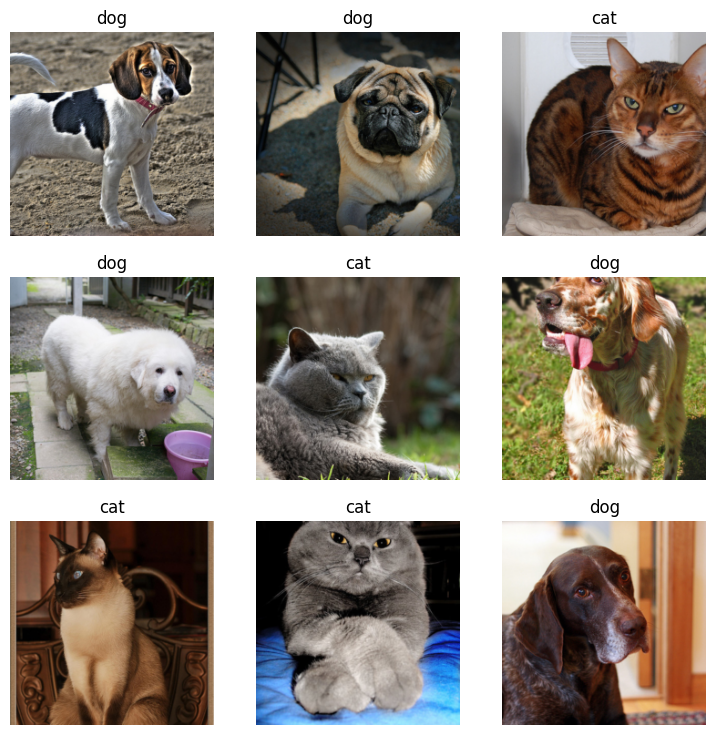

In [19]:
#Create DataLoader
dls = pets.dataloaders(img_path)
dls.show_batch()

In [ ]:
#Train Baseline Model
learn= vision_learner(dls, resnet34, metrics=accuracy)

learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.158405,0.021326,0.991881,01:11


epoch,train_loss,valid_loss,accuracy,time
0,0.055346,0.071251,0.980379,01:30
1,0.043942,0.010150,0.996617,01:31
2,0.015620,0.004685,0.998647,01:32


In [23]:
from fastdownload import download_url

url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
download_url(url, 'dog.jpg')

<div><progress max="212652" value="212992"></progress> 100.16% [212992/212652 00:00&lt;00:00]</div>

Path('dog.jpg')

<Axes: >

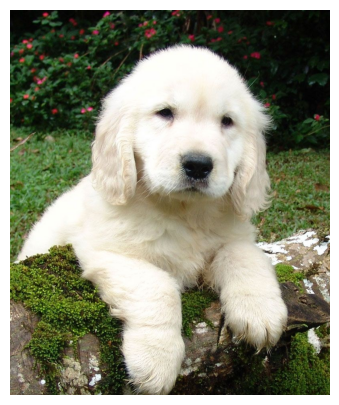

In [24]:
img = PILImage.create('dog.jpg')
img.show()

In [25]:
learn.predict(img)

('dog', tensor(1), tensor([2.0192e-07, 1.0000e+00]))

In [32]:
#DataBlock Augmentation
pets_aug = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=label_func,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

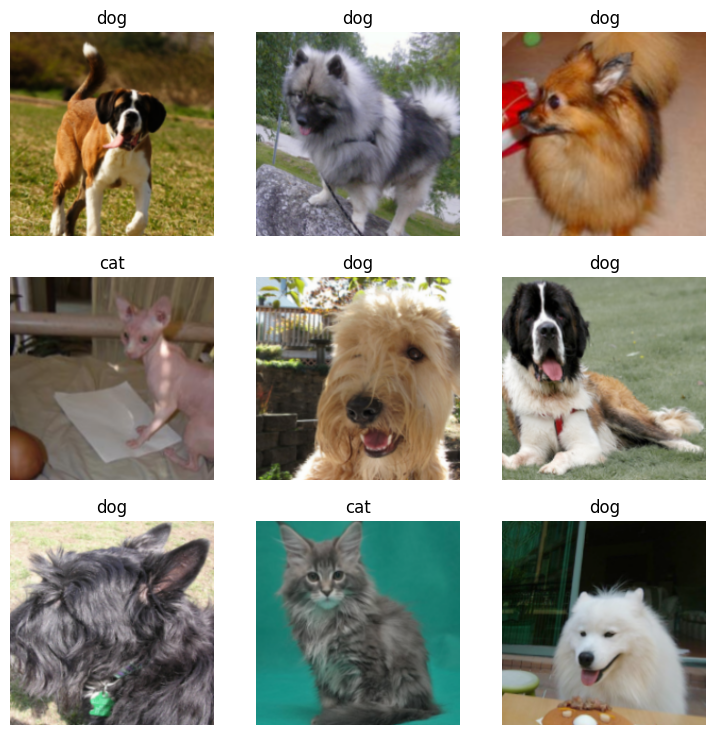

In [33]:
dls_aug = pets_aug.dataloaders(img_path)
dls_aug.show_batch()

In [34]:
#Train  Augmented  Model
device = torch.device("mps")
learn_aug = vision_learner(dls_aug, resnet34, metrics=accuracy)
learn_aug.to(device)


Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [35]:
learn_aug.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.164798,0.023202,0.994587,01:12


epoch,train_loss,valid_loss,accuracy,time
0,0.060773,0.033920,0.990528,01:38
1,0.041734,0.023013,0.991881,01:39
2,0.024419,0.012762,0.994587,01:39


<Axes: >

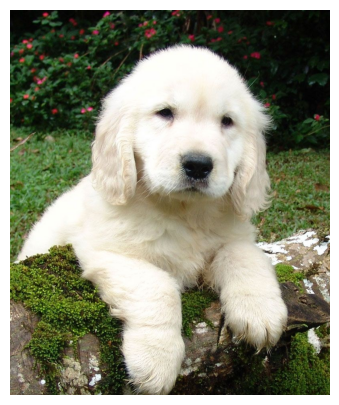

In [37]:
img_dog = PILImage.create('dog.jpg')
img_dog.show()

In [38]:
learn_aug.predict(img)

('dog', tensor(1), tensor([4.4027e-07, 1.0000e+00]))

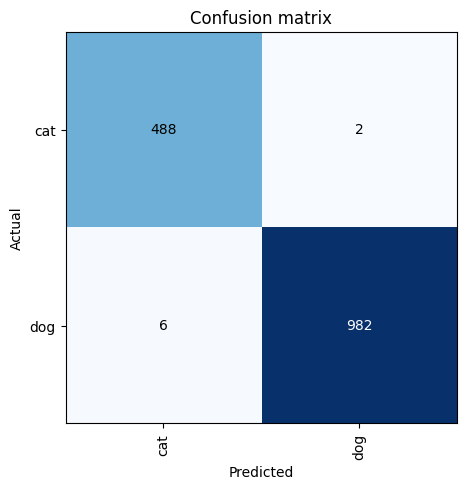

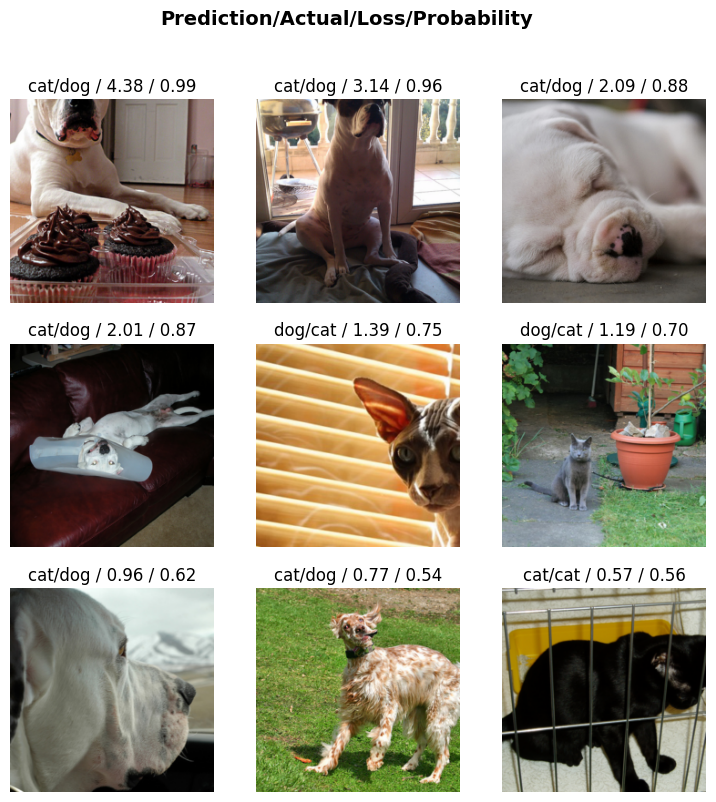

In [36]:
#Error Analysis / Interpretation
interp = ClassificationInterpretation.from_learner(learn_aug)

interp.plot_confusion_matrix()
interp.plot_top_losses(9) 

In [39]:
interp = ClassificationInterpretation.from_learner(learn_aug)

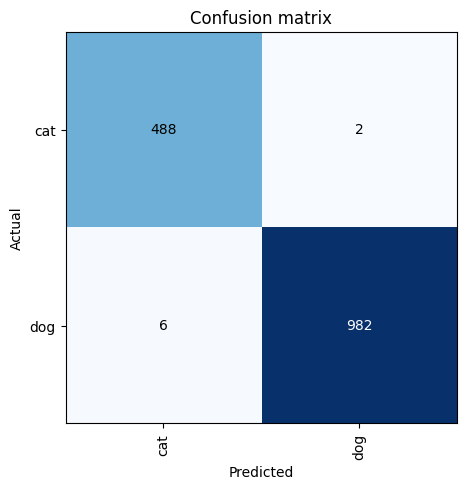

In [40]:
interp.plot_confusion_matrix()

In [41]:
cm = interp.confusion_matrix()

import pandas as pd

df = pd.DataFrame(cm, 
                  index=["Actual Cat","Actual Dog"],
                  columns=["Pred Cat","Pred Dog"])

print(df)

            Pred Cat  Pred Dog
Actual Cat       488         2
Actual Dog         6       982


In [42]:
loss_base, acc_base = learn.validate()

print("Baseline Accuracy (no augmentation):", acc_base)

Baseline Accuracy (no augmentation): 0.9986467957496643


In [43]:
loss_aug, acc_aug = learn_aug.validate()

print("Augmented Accuracy:", acc_aug)

Augmented Accuracy: 0.9945873022079468


In [44]:
print(f"Accuracy without augmentation : {acc_base:.4f}")
print(f"Accuracy with augmentation    : {acc_aug:.4f}")

Accuracy without augmentation : 0.9986
Accuracy with augmentation    : 0.9946
